Import necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

🔹 Section 1: Stereo Camera Setup

    Definition:
      # Stereo vision uses two cameras (left and right) to observe the same 3D scene.

    Importance:
      # Enables depth perception via triangulation of corresponding image points.


In [2]:
# Camera intrinsic matrix (same for both)
K = np.array([
    [800, 0, 320],
    [0, 800, 240],
    [0, 0, 1]
])

# Left camera pose (Identity - at origin)
R1 = np.eye(3)
t1 = np.zeros((3, 1))
P1 = K @ np.hstack((R1, t1))  # Projection matrix for left camera

# Right camera pose (translated along X by baseline)
baseline = 0.5  # 50 cm between cameras
R2 = np.eye(3)
t2 = np.array([[-baseline], [0], [0]])
P2 = K @ np.hstack((R2, t2))  # Projection matrix for right camera

🔹 Section 2: Generate 3D Points and Project to Both Cameras


    Importance:
        # Simulates 3D world points and their 2D projections to form stereo correspondences.


In [3]:
# 3D points in front of both cameras
X_world = np.array([
    [1, 1, 5],
    [2, 1, 6],
    [1, 2, 7],
    [2, 2, 8],
    [1.5, 1.5, 6]
]).T  # shape (3, N)
X_world_h = np.vstack((X_world, np.ones((1, X_world.shape[1]))))  # homogeneous

# Project to both cameras
x1_h = P1 @ X_world_h
x2_h = P2 @ X_world_h
x1 = x1_h[:2] / x1_h[2]
x2 = x2_h[:2] / x2_h[2]

🔹 Section 3: Visualize Stereo Setup and Projections

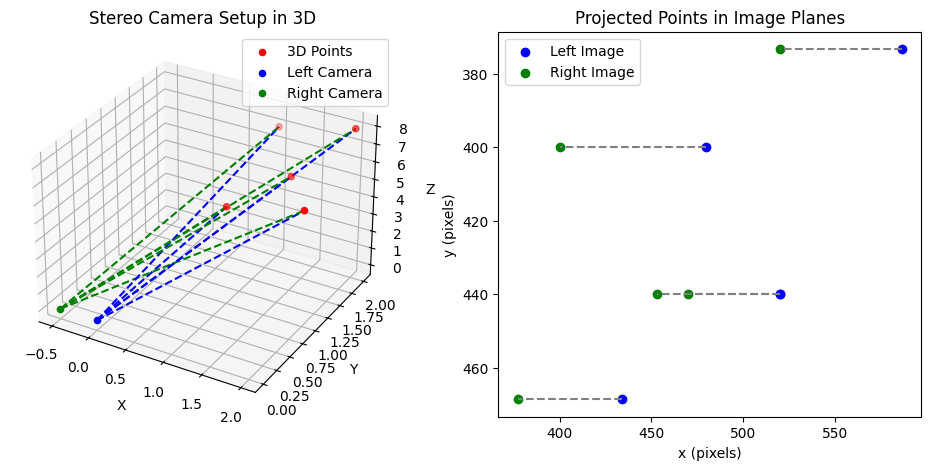

In [4]:
fig = plt.figure(figsize=(12, 5))

# 3D setup
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(*X_world, c='red', label='3D Points')
ax1.scatter(0, 0, 0, color='blue', label='Left Camera')
ax1.scatter(-baseline, 0, 0, color='green', label='Right Camera')
for i in range(X_world.shape[1]):
    ax1.plot([0, X_world[0, i]], [0, X_world[1, i]], [0, X_world[2, i]], 'b--')
    ax1.plot([-baseline, X_world[0, i]], [0, X_world[1, i]], [0, X_world[2, i]], 'g--')
ax1.set_title("Stereo Camera Setup in 3D")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.legend()

# 2D projections
ax2 = fig.add_subplot(122)
ax2.scatter(x1[0], x1[1], label='Left Image', color='blue')
ax2.scatter(x2[0], x2[1], label='Right Image', color='green')
for i in range(x1.shape[1]):
    ax2.plot([x1[0, i], x2[0, i]], [x1[1, i], x2[1, i]], 'gray', linestyle='--')
ax2.set_title("Projected Points in Image Planes")
ax2.set_xlabel("x (pixels)")
ax2.set_ylabel("y (pixels)")
ax2.legend()
ax2.invert_yaxis()
plt.show()

🔹 Section 4: Epipolar Geometry and Fundamental Matrix

    Definition:
        # F relates points in one image to epipolar lines in the other.

    Formula:
        x2^T * F * x1 = 0

    Importance:
        # Constrains search for matching points to 1D epipolar lines.


In [5]:
# Skew-symmetric matrix for translation t
def skew(t):
    return np.array([
        [0, -t[2], t[1]],
        [t[2], 0, -t[0]],
        [-t[1], t[0], 0]
    ])

T = skew(t2.flatten())
R = R2 @ R1.T
E = T @ R  # Essential matrix
F = np.linalg.inv(K).T @ E @ np.linalg.inv(K)  # Fundamental matrix

print("Fundamental Matrix F:\n", F)

Fundamental Matrix F:
 [[ 0.        0.        0.      ]
 [ 0.        0.        0.000625]
 [ 0.       -0.000625  0.      ]]


🔹 Section 5: Pure Translation - Compute Depth from Disparity

    Formula:
        disparity = x_left - x_right
        Z = f * B / disparity

    Importance:
        Simple stereo depth computation under rectified pure translation.

In [6]:
# Get disparity (assume rectified, so y1 ≈ y2)
disparity = x1[0] - x2[0]
depth = K[0, 0] * baseline / disparity  # f * B / d

print("\nDepth from disparity:")
for i, d in enumerate(depth):
    print(f"Point {i}: Disparity = {disparity[i]:.2f}, Depth = {d:.2f} m")


Depth from disparity:
Point 0: Disparity = 80.00, Depth = 5.00 m
Point 1: Disparity = 66.67, Depth = 6.00 m
Point 2: Disparity = 57.14, Depth = 7.00 m
Point 3: Disparity = 50.00, Depth = 8.00 m
Point 4: Disparity = 66.67, Depth = 6.00 m


🔹 Section 6: General Motion - Triangulation
    
    Definition:
        # General camera motion requires triangulation to recover 3D from 2D correspondences.

    Importance:
        # Works beyond pure translation or rectified setups.

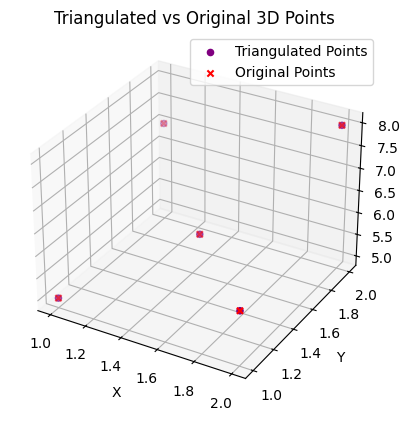

In [7]:
def triangulate_point(p1, p2, P1, P2):
    A = np.array([
        p1[0] * P1[2] - P1[0],
        p1[1] * P1[2] - P1[1],
        p2[0] * P2[2] - P2[0],
        p2[1] * P2[2] - P2[1]
    ])
    U, S, Vt = np.linalg.svd(A)
    X = Vt[-1]
    return X[:3] / X[3]

triangulated = np.array([triangulate_point(x1[:, i], x2[:, i], P1, P2) for i in range(x1.shape[1])]).T

# Visualize triangulated 3D points
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(*triangulated, color='purple', label='Triangulated Points')
ax.scatter(*X_world, color='red', marker='x', label='Original Points')
ax.set_title("Triangulated vs Original 3D Points")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()